# BYU CS 473 — K-Nearest Neighbors

In this assignment, you will explore **KNN classification** using different distance metrics, understand the **curse of dimensionality**, and learn how KNN can be adapted for **open set recognition** and **out-of-distribution (OOD) detection**.

---

## Learning Goals
- Understand and compare different distance metrics in KNN
- Explore the effect of high-dimensional data (curse of dimensionality)
- Implement open set recognition with KNN
- Apply KNN for simple OOD detection


## 1. Loading the Iris Dataset

We begin with the Iris dataset.


In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Exercise 1
Print the shapes of the training and test sets, and display the first 5 rows of `X_train`.


In [12]:
# Your code here

## 2. KNN with Different Distance Metrics

KNN relies on a distance function to measure similarity. Common choices include:

- **Euclidean** (straight-line distance)  
- **Manhattan** (sum of absolute differences)  
- **Chebyshev** (max difference)  
- **Mahalanobis** (accounts for correlations between features)  


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

distances = ["euclidean", "manhattan", "chebyshev"]

for d in distances:
    knn = KNeighborsClassifier(n_neighbors=5, metric=d)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Metric: {d}, Accuracy: {acc:.3f}")


Metric: euclidean, Accuracy: 1.000
Metric: manhattan, Accuracy: 1.000
Metric: chebyshev, Accuracy: 0.956


### Exercise 2
Add **Mahalanobis distance** to the code above.  
Hint: compute the covariance matrix and pass it via `metric_params`.  

Which distance metric performed best? Why might that be the case?

Your response here

## 3. Curse of Dimensionality

As the number of features increases, distances between points become less meaningful.  
We will test KNN on synthetic datasets with increasing dimensionality.


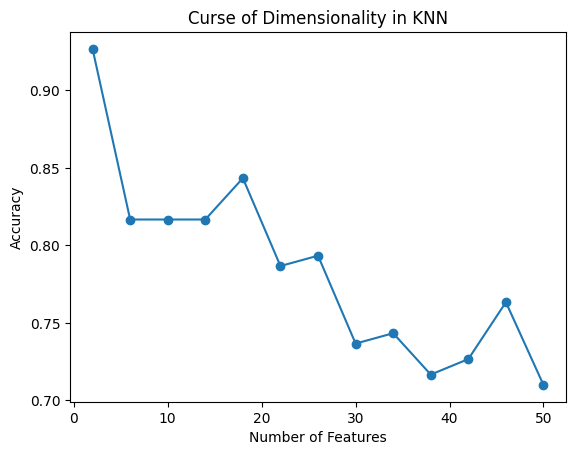

In [18]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

dims = range(2, 51, 4)
accuracies = []

for d in dims:
    X_high, y_high = make_classification(
        n_samples=1000,
        n_features=d,
        n_informative=2,
        n_redundant=0,
        n_repeated=0,
        random_state=42
    )
    X_tr, X_te, y_tr, y_te = train_test_split(X_high, y_high, test_size=0.3, random_state=42)
    knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
    knn.fit(X_tr, y_tr)
    acc = knn.score(X_te, y_te)
    accuracies.append(acc)

plt.plot(dims, accuracies, marker="o")
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Curse of Dimensionality in KNN")
plt.show()


### Exercise 3
Modify the code above to also test **Manhattan distance** and plot both curves together.

What happens to accuracy as dimensionality increases? Why?

Your response here

## 4. Open Set Recognition

KNN assumes all test samples belong to known classes. But in practice, a test point may not belong to any training class.

We simulate this by generating a synthetic "unknown" dataset.


In [15]:
import numpy as np

from sklearn.datasets import make_classification

# Synthetic unknown samples
X_unknown, y_unknown = make_classification(n_samples=200, n_features=4, n_classes=1, random_state=99)

knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

unknown_preds = knn.predict(X_unknown)
print("Unique predictions for unknown samples:", np.unique(unknown_preds))


Unique predictions for unknown samples: [0 1 2]


### Exercise 4
Modify the code to compute the distance to the nearest neighbor for each unknown sample.  
If the distance is above a threshold, classify it as **unknown**.

How does thresholding improve open set recognition?

Your response here

## 5. Out-of-Distribution (OOD) Detection

OOD detection identifies samples that do not belong to the same distribution as the training data.


In [16]:
from sklearn.metrics import pairwise_distances

in_dist = pairwise_distances(X_test, X_train).min(axis=1)
out_dist = pairwise_distances(X_unknown, X_train).min(axis=1)

print("Average distance (in-distribution):", np.mean(in_dist))
print("Average distance (OOD):", np.mean(out_dist))

Average distance (in-distribution): 0.31853062619139316
Average distance (OOD): 1.2213708916568842


## Exersise 5
Plot histograms of `in_dist` and `out_dist` on the same figure.  
What do you observe?
Suggest a thresholding rule to separate in-distribution from OOD samples.

Your response here

## 6. Reflection

1. Which distance metric was most robust?  
2. How did dimensionality affect KNN performance?  
3. Why is open set recognition important?  
4. How might KNN be adapted for stronger OOD detection?  


Your response here